## Install & Import dependencies | Dataset creation

In [ ]:
!pip install "ray[tune]" torch torchvision mlflow pytorch-forecasting onnxscript optuna onnxmltools onnxconverter_common onnxruntime --upgrade

  Using cached mlflow-3.8.1-py3-none-any.whl.metadata (31 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mlflow_skinny-3.8.1-py3-none-any.whl.metadata (31 kB)
  Using cached mlflow_tracing-3.8.1-py3-none-any.whl.metadata (19 kB)
  Using cached flask-3.1.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached sqlparse-0.5.5-py3-none-any.whl.metadata (4.7 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using c

In [44]:
!pip install yfinance --upgrade seaborn statsmodels lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.1 MB/s  0:00:00


In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from statsmodels.tsa.stattools import adfuller

tickers = [
  "EURUSD=X",
  "GBPUSD=X",
  "USDJPY=X",
  "USDCHF=X",
  "USDCAD=X",
  "AUDUSD=X",
  "NZDUSD=X",
  "EURMAD=X",
  "EURRUB=X",
  "RUBUSD=X"
]

In [10]:
df = yf.download(
    tickers,
    start = "2000-01-01",
    end = "2026-01-01",
    interval = "1d",
    group_by = "ticker",
    threads=True
)

[*********************100%***********************]  10 of 10 completed


In [11]:
df.tail()

Ticker     EURMAD=X                                     EURRUB=X             \
Price          Open     High      Low    Close Volume       Open       High   
Date                                                                          
2025-12-24  10.4187  10.4195  10.4187  10.4187    0.0  91.994598  93.121498   
2025-12-26  10.4187  10.4195  10.4187  10.4187    0.0  93.014099  93.121498   
2025-12-29  10.3754  10.3754  10.3754  10.4195    0.0  93.014099  92.433800   
2025-12-30  10.3754  10.3754  10.3717  10.3754    0.0  92.410400  93.885002   
2025-12-31  10.3717  10.3719  10.3717  10.3717    0.0  93.374298  96.670097   

Ticker                                   ...  GBPUSD=X                      \
Price             Low      Close Volume  ...      Open      High       Low   
Date                                     ...                                 
2025-12-24  91.882599  91.994598    0.0  ...  1.351388  1.353546  1.349382   
2025-12-26  91.882599  93.014099    0.0  ...  1.350713  1.352667  1.347782   
2025-12-29  90.083801  93.014099    0.0  ...  1.350074  1.351351  1.347128   
2025-12-30  91.879097  92.406898    0.0  ...  1.350986  1.353015  1.345171   
2025-12-31  91.349998  93.381401    0.0  ...  1.346783  1.347654  1.340339   

Ticker                       RUBUSD=X                                       
Price          Close Volume      Open      High       Low     Close Volume  
Date                                                                        
2025-12-24  1.351360    0.0  0.012821  0.012824  0.012657  0.012821    0.0  
2025-12-26  1.350895    0.0  0.012666  0.012681  0.012644  0.012667    0.0  
2025-12-29  1.349728    0.0  0.012655  0.013073  0.012634  0.012653    0.0  
2025-12-30  1.351099    0.0  0.012739  0.012814  0.012530  0.012739    0.0  
2025-12-31  1.346720    0.0  0.012580  0.012852  0.012158  0.012579    0.0  

[5 rows x 50 columns]

In [12]:
df["NZDUSD=X"]

Price,Open,High,Low,Close,Volume
Date,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN
2000-01-04,NaN,NaN,NaN,NaN,NaN
2000-01-05,NaN,NaN,NaN,NaN,NaN
2000-01-06,NaN,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2025-12-24,0.584378,0.585329,0.583359,0.584300,0.0
2025-12-26,0.583591,0.584290,0.581889,0.583642,0.0
2025-12-29,0.582791,0.583400,0.579119,0.582610,0.0


## Exploratory Data Analysis

In [13]:
for ticker in tickers:
  print(df[ticker].info)

<bound method DataFrame.info of Price           Open      High       Low     Close  Volume
Date                                                      
2000-01-03       NaN       NaN       NaN       NaN     NaN
2000-01-04       NaN       NaN       NaN       NaN     NaN
2000-01-05       NaN       NaN       NaN       NaN     NaN
2000-01-06       NaN       NaN       NaN       NaN     NaN
2000-01-07       NaN       NaN       NaN       NaN     NaN
...              ...       ...       ...       ...     ...
2025-12-24  1.179565  1.180916  1.177426  1.179551     0.0
2025-12-26  1.178384  1.179941  1.176304  1.178536     0.0
2025-12-29  1.177496  1.178856  1.175406  1.177274     0.0
2025-12-30  1.177302  1.178134  1.174619  1.177288     0.0
2025-12-31  1.174646  1.175876  1.172086  1.174729     0.0

[6774 rows x 5 columns]>
<bound method DataFrame.info of Price           Open      High       Low     Close  Volume
Date                                                      
2000-01-03       NaN     

In [14]:
df.dtypes

Ticker    Price 
EURMAD=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
EURRUB=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
USDCAD=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
USDCHF=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
USDJPY=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
AUDUSD=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
NZDUSD=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
EUR

In [15]:
print(f"Shape: {df.shape}")
print(f"Statistical Summary: {df.describe()}")

Shape: (6774, 50)
Statistical Summary: Ticker     EURMAD=X                                                 \
Price          Open         High          Low        Close  Volume   
count   4803.000000  4803.000000  4803.000000  4803.000000  4803.0   
mean      10.658477    10.689410    10.629403    10.654018     0.0   
std        0.285358     0.299152     0.278590     0.282520     0.0   
min        9.952200     9.954700     9.750000     9.794000     0.0   
25%       10.446750    10.465950    10.424500    10.446300     0.0   
50%       10.648000    10.688000    10.622900    10.644000     0.0   
75%       10.880000    10.920000    10.843000    10.875000     0.0   
max       11.306000    11.328000    11.277000    11.301000     0.0   

Ticker     EURRUB=X                                                 ...  \
Price          Open         High          Low        Close  Volume  ...   
count   5263.000000  5263.000000  5263.000000  5263.000000  5263.0  ...   
mean      62.051127    62.597862   

In [16]:
# Identify missing values:
print(df.isnull().sum())

Ticker    Price 
EURMAD=X  Open      1971
          High      1971
          Low       1971
          Close     1971
          Volume    1971
EURRUB=X  Open      1511
          High      1511
          Low       1511
          Close     1511
          Volume    1511
USDCAD=X  Open       976
          High       976
          Low        976
          Close      976
          Volume     976
USDCHF=X  Open       978
          High       978
          Low        978
          Close      978
          Volume     978
USDJPY=X  Open        24
          High        24
          Low         24
          Close       24
          Volume      24
AUDUSD=X  Open      1668
          High      1668
          Low       1668
          Close     1668
          Volume    1668
NZDUSD=X  Open      1043
          High      1043
          Low       1043
          Close     1043
          Volume    1043
EURUSD=X  Open      1044
          High      1044
          Low       1044
          Close     1044
        

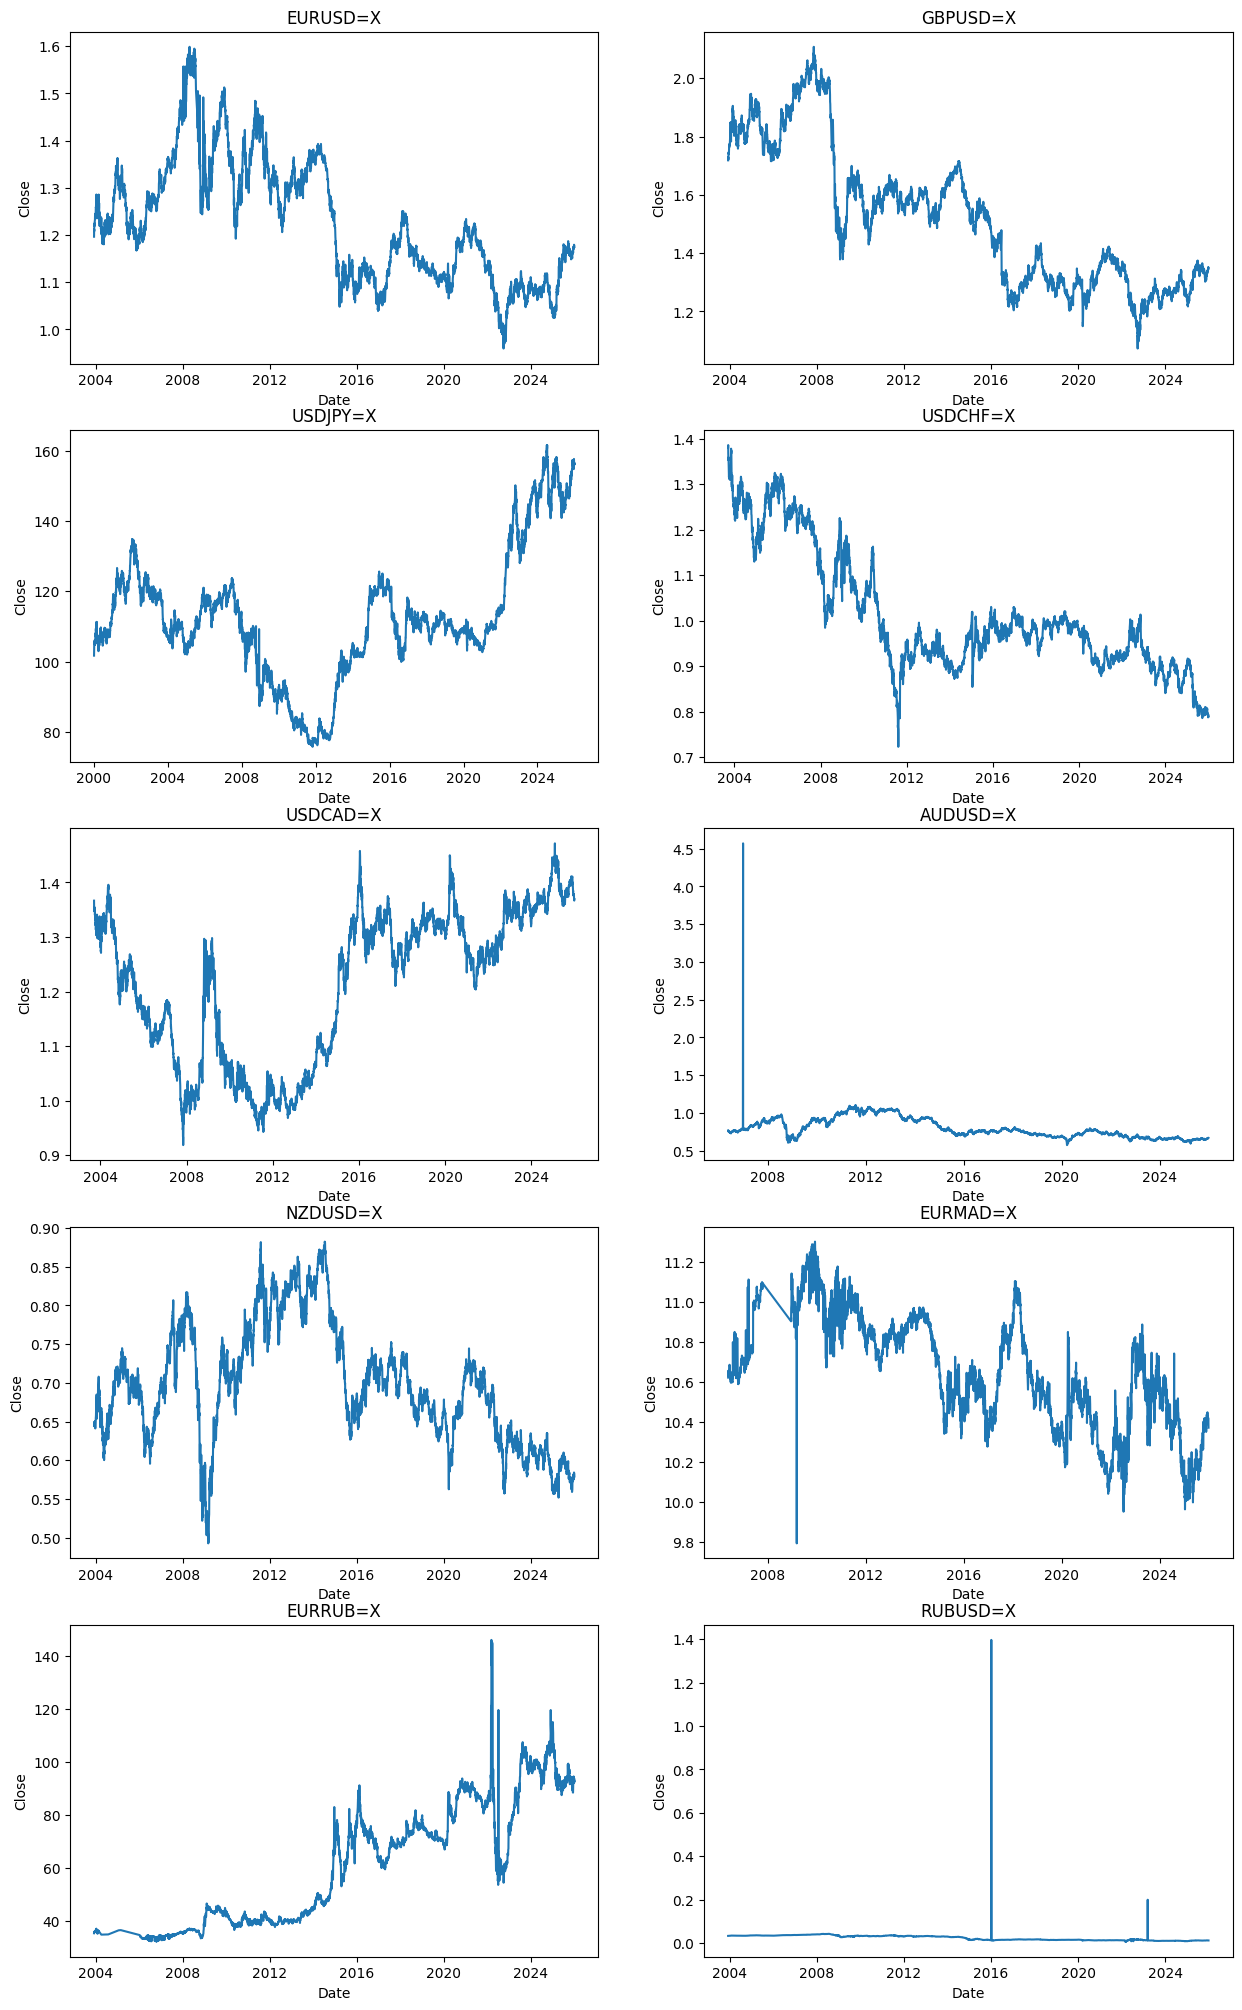

In [17]:
fig = plt.figure(figsize=(15, 25))
for ticker in tickers:
  ax = fig.add_subplot(5, 2, tickers.index(ticker)+1)
  sns.lineplot(x=df.index, y=df[ticker]["Close"], ax=ax)
  ax.set_title(ticker)
plt.show()

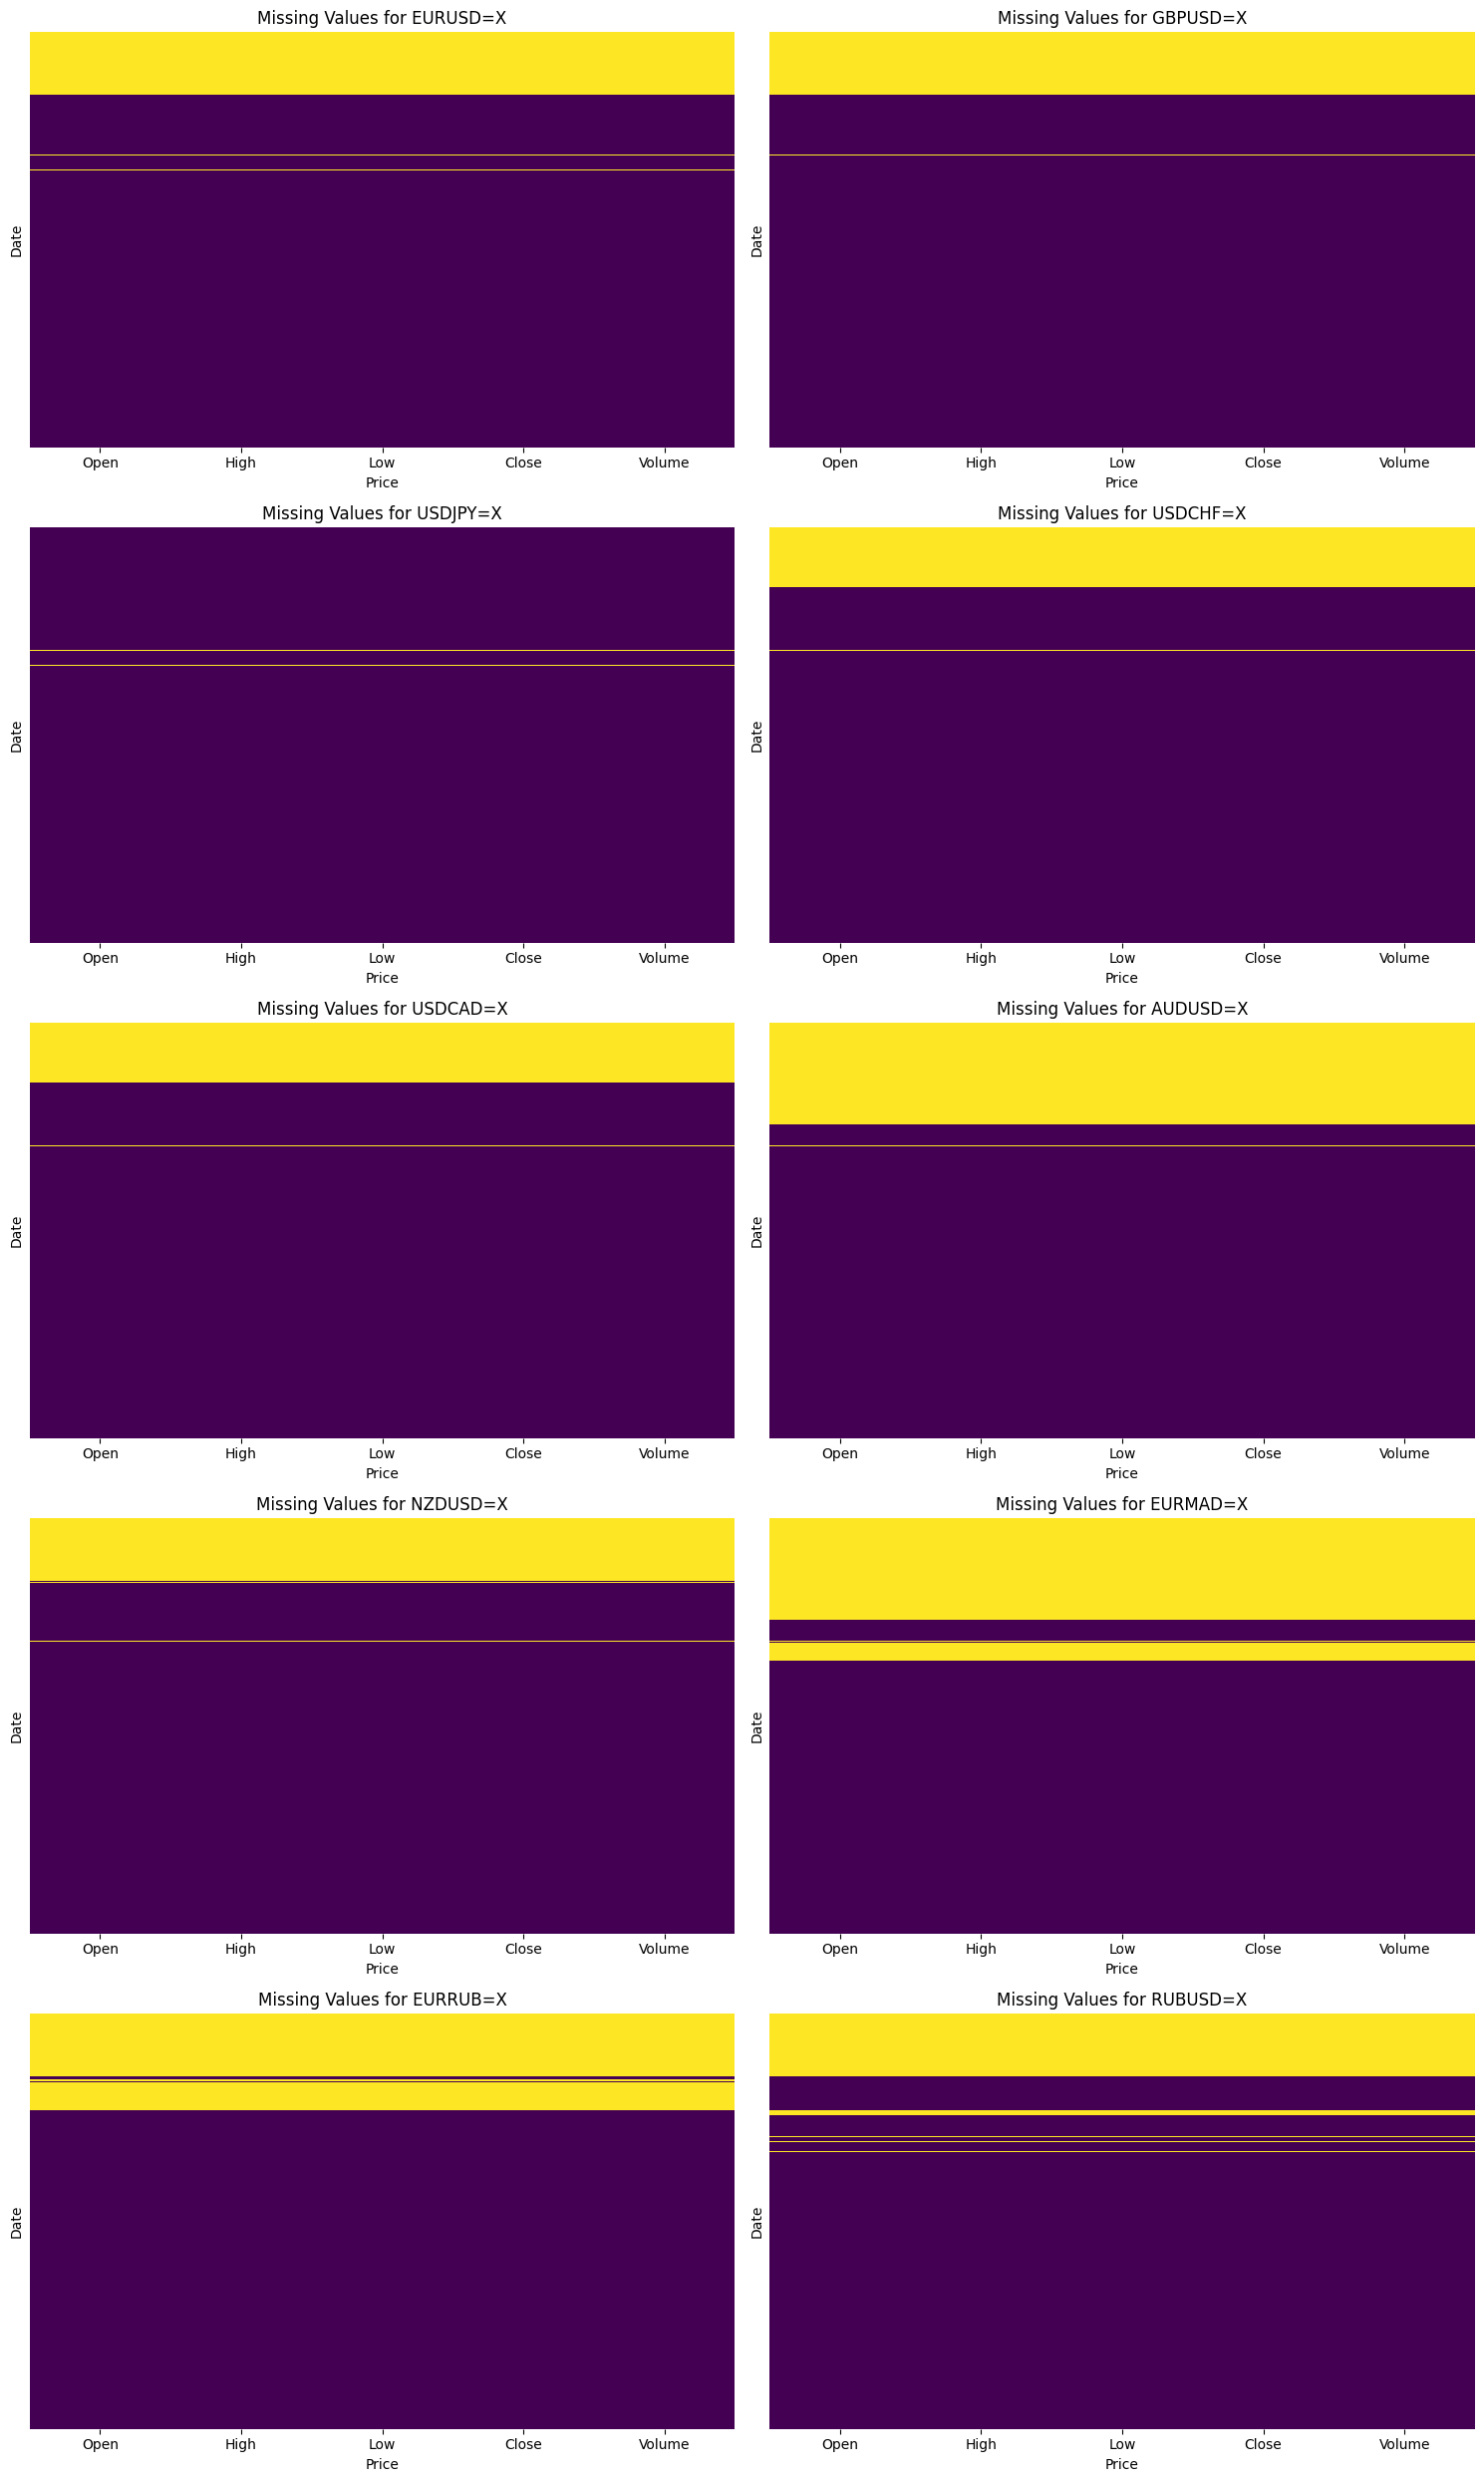

In [18]:
fig = plt.figure(figsize=(15, 25))
for i, ticker in enumerate(tickers):
  ax = fig.add_subplot(5, 2, i + 1)
  sns.heatmap(data=df[ticker].isnull(), yticklabels=False, cbar=False, cmap="viridis", ax=ax)
  ax.set_title(f'Missing Values for {ticker}')
plt.tight_layout()
plt.show()

In [19]:
# Handling missing values in times series can be done with 2 methods either Forward or Backward fill
df.fillna(method="ffill", inplace=True)
df.fillna(method="bfill", inplace=True)
df.isnull().sum()

C:\Users\Karim\AppData\Local\Temp\ipykernel_11792\3846587118.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)
C:\Users\Karim\AppData\Local\Temp\ipykernel_11792\3846587118.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="bfill", inplace=True)


Ticker    Price 
EURMAD=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
EURRUB=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
USDCAD=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
USDCHF=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
USDJPY=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
AUDUSD=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
NZDUSD=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
EURUSD=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
GBPUSD=X  Open      0
          High      0
          Low       0
          Close     0
          Volum

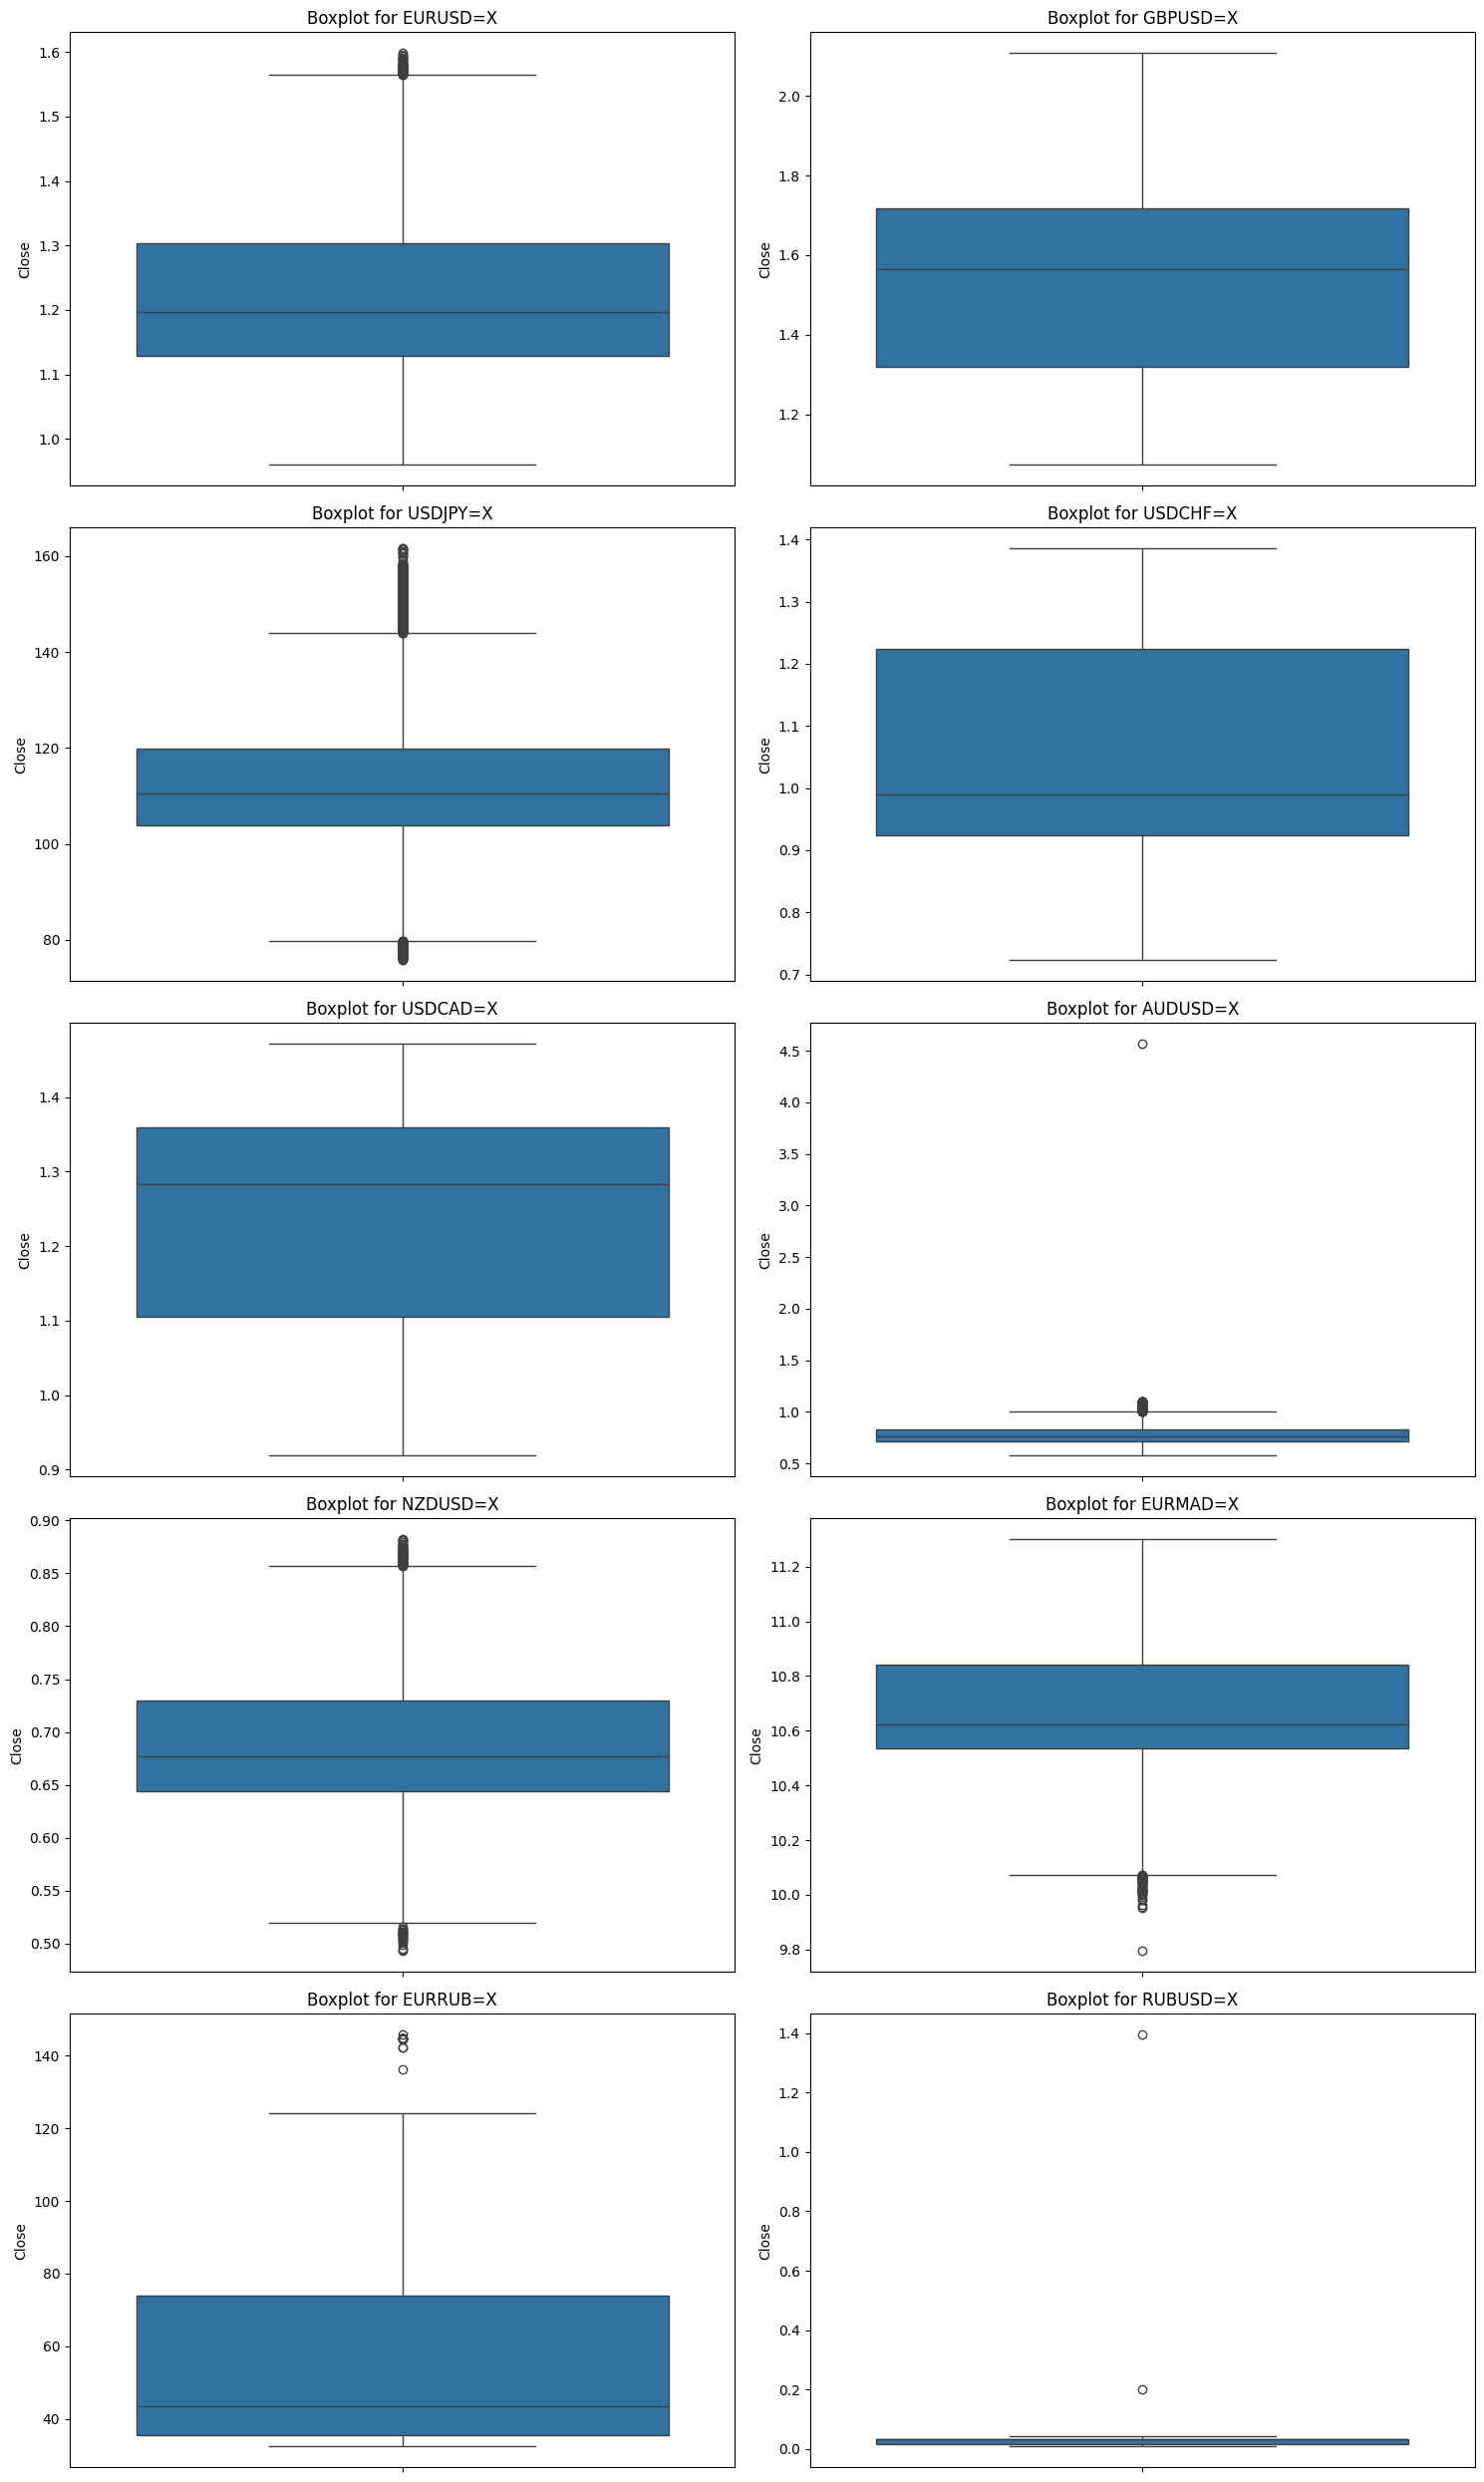

In [20]:
fig = plt.figure(figsize=(15, 25))
for i, ticker in enumerate(tickers):
  ax = fig.add_subplot(5, 2, i + 1)
  sns.boxplot(y=df[ticker]["Close"], ax = ax)
  ax.set_title(f'Boxplot for {ticker}')
plt.tight_layout()
plt.show()

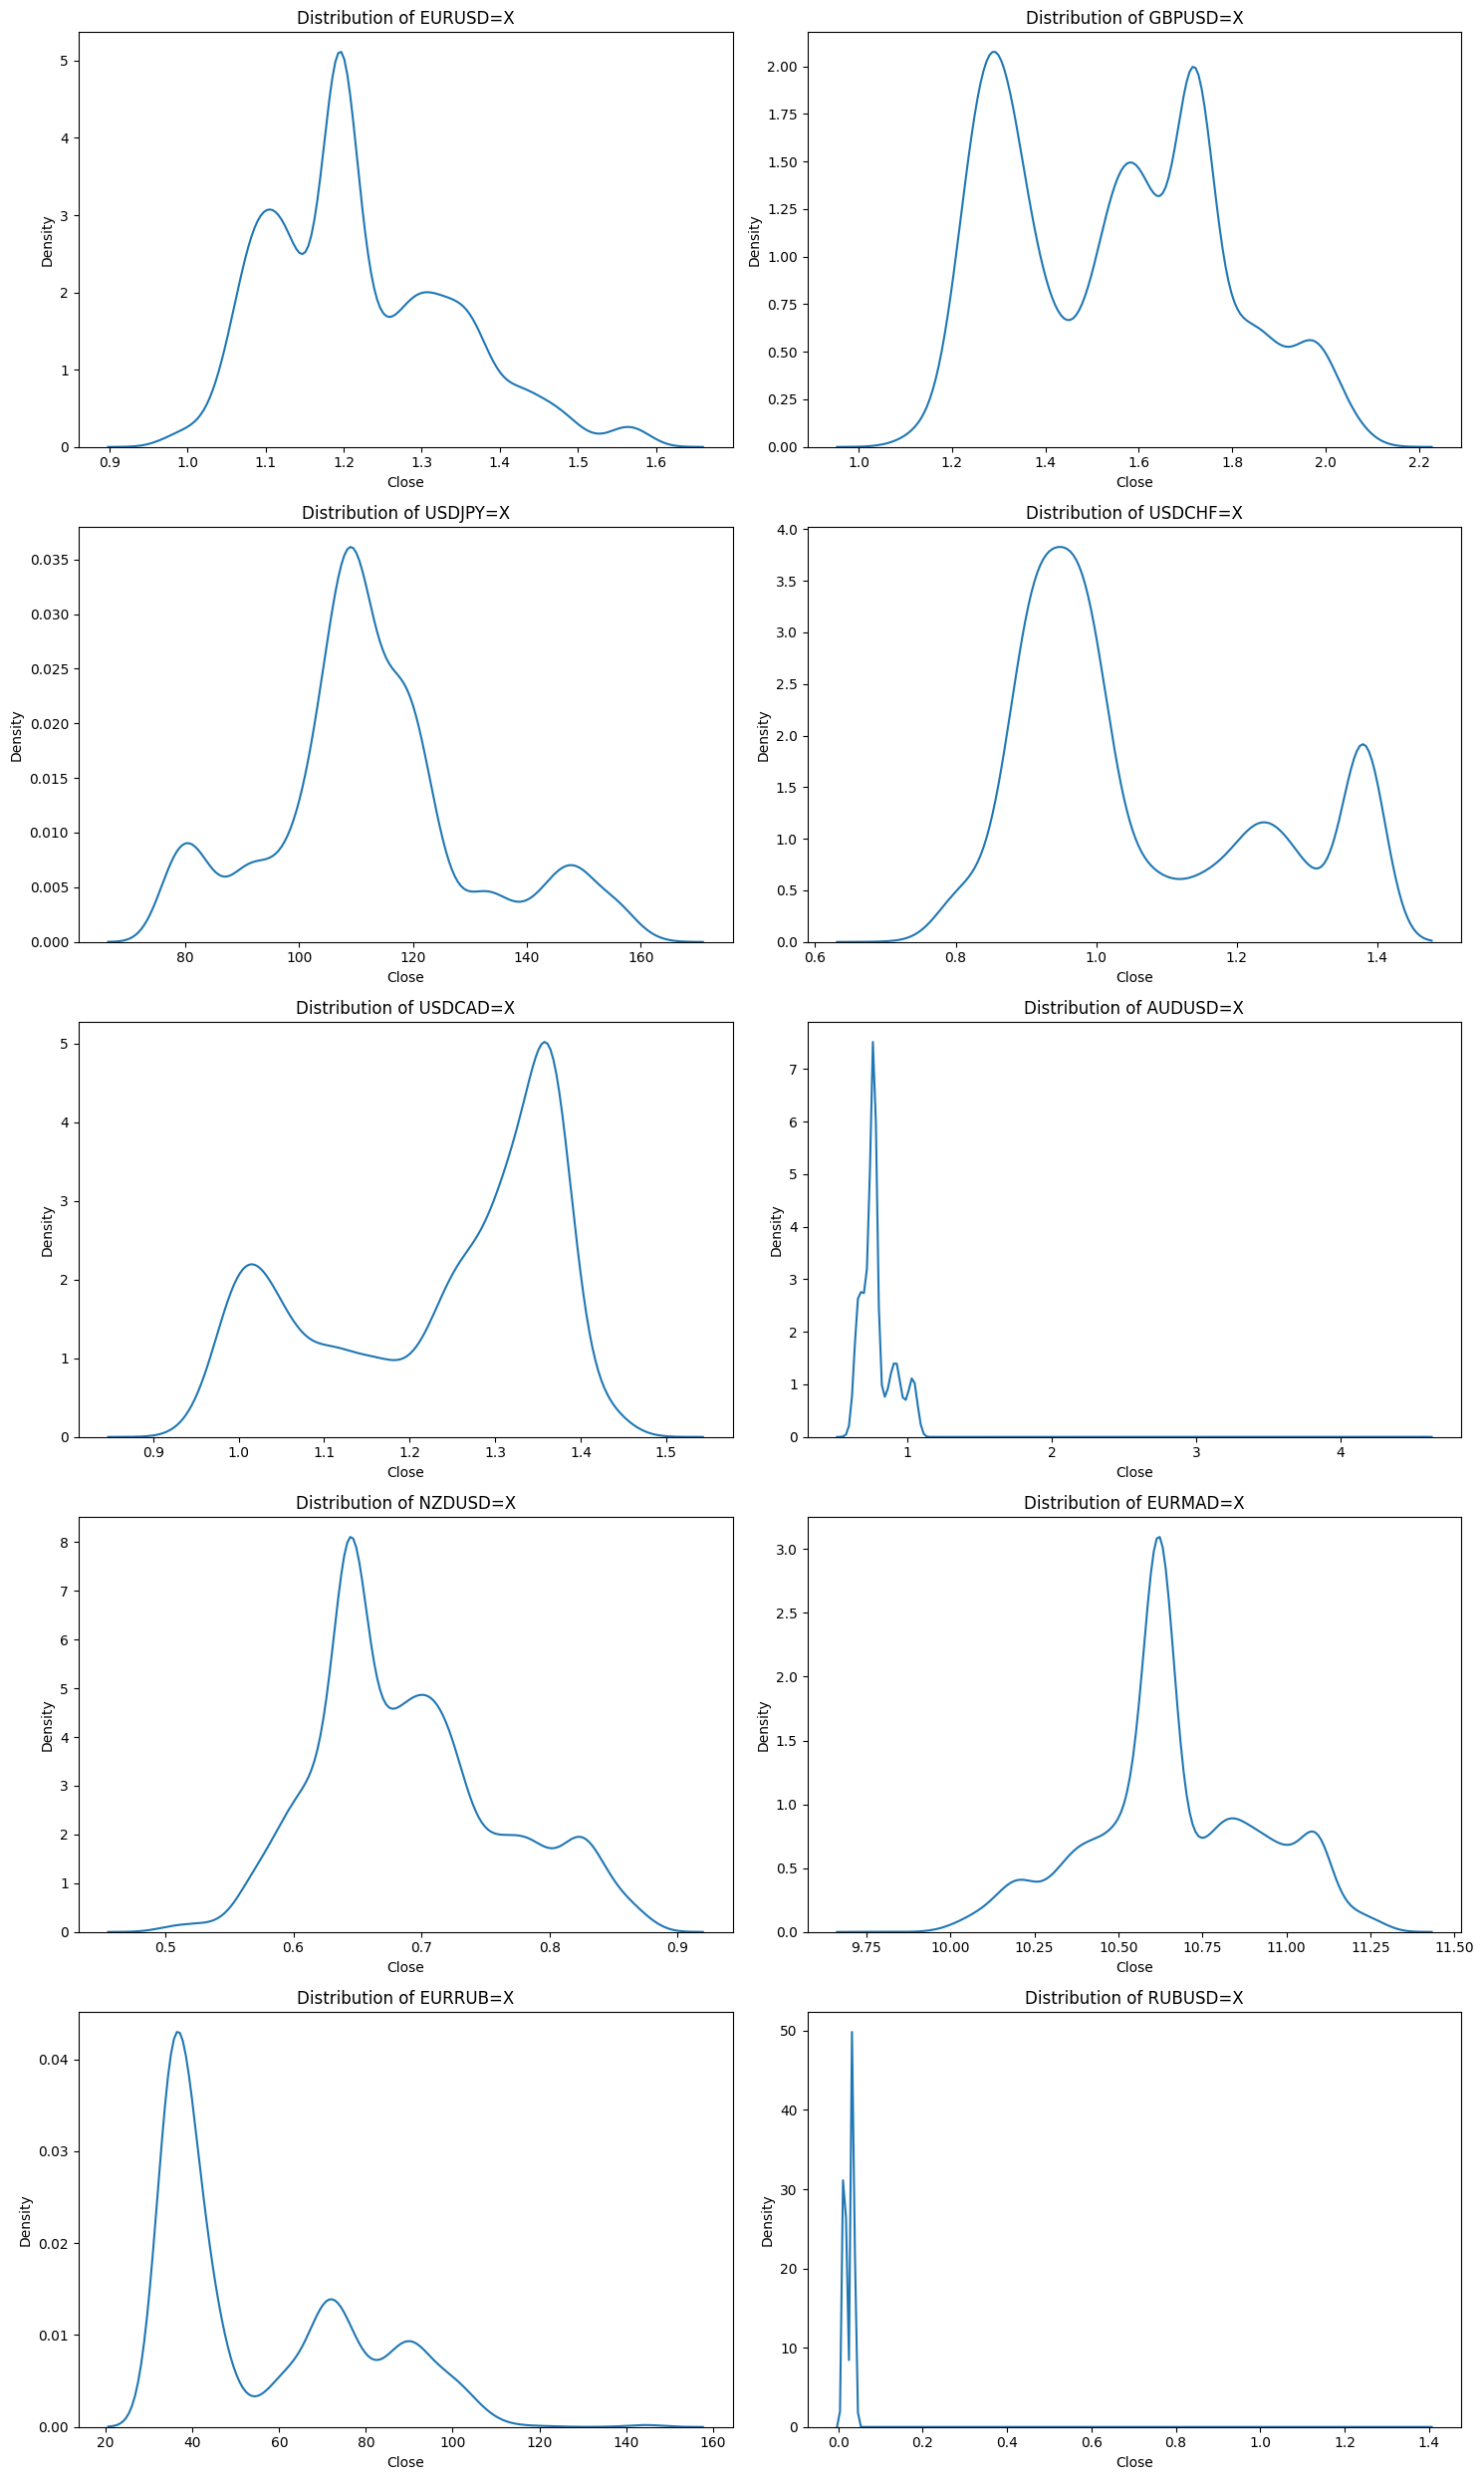

In [21]:
fig = plt.figure(figsize=(15, 25))
for i, ticker in enumerate(tickers):
  ax = fig.add_subplot(5, 2, i+1)
  sns.kdeplot(df[ticker]['Close'], ax=ax)
  ax.set_title(f'Distribution of {ticker}')
  ax.set_xlabel('Close')
  ax.set_ylabel('Density')
  plt.tight_layout()
plt.show()

In [22]:
df_zscore = df.apply(zscore)
columns_to_drop = [(ticker, 'Volume') for ticker in tickers]
print(columns_to_drop)
df_zscore= df_zscore.drop(columns= columns_to_drop)
display(df_zscore.head())

[('EURUSD=X', 'Volume'), ('GBPUSD=X', 'Volume'), ('USDJPY=X', 'Volume'), ('USDCHF=X', 'Volume'), ('USDCAD=X', 'Volume'), ('AUDUSD=X', 'Volume'), ('NZDUSD=X', 'Volume'), ('EURMAD=X', 'Volume'), ('EURRUB=X', 'Volume'), ('RUBUSD=X', 'Volume')]


Ticker      EURMAD=X                                EURRUB=X            \
Price           Open      High       Low     Close      Open      High   
Date                                                                     
2000-01-03  0.371816  0.339793 -0.100293 -0.172212 -0.895837 -0.898997   
2000-01-04  0.371816  0.339793 -0.100293 -0.172212 -0.895837 -0.898997   
2000-01-05  0.371816  0.339793 -0.100293 -0.172212 -0.895837 -0.898997   
2000-01-06  0.371816  0.339793 -0.100293 -0.172212 -0.895837 -0.898997   
2000-01-07  0.371816  0.339793 -0.100293 -0.172212 -0.895837 -0.898997   

Ticker                        USDCAD=X            ... EURUSD=X            \
Price            Low   Close      Open      High  ...      Low     Close   
Date                                              ...                      
2000-01-03 -0.909199 -0.9023  0.961287  0.957737  ... -0.19097 -0.210937   
2000-01-04 -0.909199 -0.9023  0.961287  0.957737  ... -0.19097 -0.210937   
2000-01-05 -0.909199 -0.9023  0.961287  0.957737  ... -0.19097 -0.210937   
2000-01-06 -0.909199 -0.9023  0.961287  0.957737  ... -0.19097 -0.210937   
2000-01-07 -0.909199 -0.9023  0.961287  0.957737  ... -0.19097 -0.210937   

Ticker      GBPUSD=X                                RUBUSD=X            \
Price           Open      High       Low     Close      Open      High   
Date                                                                     
2000-01-03  0.750428  0.740825  0.753468  0.732958  0.783183  0.778896   
2000-01-04  0.750428  0.740825  0.753468  0.732958  0.783183  0.778896   
2000-01-05  0.750428  0.740825  0.753468  0.732958  0.783183  0.778896   
2000-01-06  0.750428  0.740825  0.753468  0.732958  0.783183  0.778896   
2000-01-07  0.750428  0.740825  0.753468  0.732958  0.783183  0.778896   

Ticker                         
Price           Low     Close  
Date                           
2000-01-03  0.79223  0.396322  
2000-01-04  0.79223  0.396322  
2000-01-05  0.79223  0.396322  
2000-01-06  0.79223  0.396322  
2000-01-07  0.79223  0.396322  

[5 rows x 40 columns]

In [23]:
outliers_count = (np.abs(df_zscore) > 3).sum()
print(f"Number of outliers in each column:\n{outliers_count}")

Number of outliers in each column:
Ticker    Price
EURMAD=X  Open      0
          High      0
          Low       1
          Close     1
EURRUB=X  Open     14
          High     18
          Low       6
          Close    15
USDCAD=X  Open      0
          High      0
          Low       0
          Close     0
USDCHF=X  Open      0
          High      0
          Low       0
          Close     0
USDJPY=X  Open      0
          High      0
          Low       0
          Close     0
AUDUSD=X  Open      1
          High      2
          Low       0
          Close     1
NZDUSD=X  Open      0
          High      3
          Low       0
          Close     0
EURUSD=X  Open     27
          High     26
          Low      24
          Close    25
GBPUSD=X  Open      0
          High      0
          Low       1
          Close     0
RUBUSD=X  Open      0
          High      0
          Low       0
          Close     2
dtype: int64


In [24]:
outliers_count = (np.abs(df_zscore) > 3).sum()
print(f"Number of outliers in each column:\n{outliers_count}")

Number of outliers in each column:
Ticker    Price
EURMAD=X  Open      0
          High      0
          Low       1
          Close     1
EURRUB=X  Open     14
          High     18
          Low       6
          Close    15
USDCAD=X  Open      0
          High      0
          Low       0
          Close     0
USDCHF=X  Open      0
          High      0
          Low       0
          Close     0
USDJPY=X  Open      0
          High      0
          Low       0
          Close     0
AUDUSD=X  Open      1
          High      2
          Low       0
          Close     1
NZDUSD=X  Open      0
          High      3
          Low       0
          Close     0
EURUSD=X  Open     27
          High     26
          Low      24
          Close    25
GBPUSD=X  Open      0
          High      0
          Low       1
          Close     0
RUBUSD=X  Open      0
          High      0
          Low       0
          Close     2
dtype: int64


Reasons behind these outlier dates:
1. August 2011: The Swiss Franc (CHF) experienced a period of significant appreciation during this time, driven by its safe-haven status amidst the Eurozone debt crisis. The values dipping from ~1.1x to ~0.7x are indeed a stark deviation.

2. January 15, 2015: This date is famously known as 'Swiss National Bank (SNB) Black Thursday' or 'Francogeddon'. On this day, the SNB unexpectedly removed its cap on the Swiss franc against the euro, causing massive and sudden movements in the CHF, including against the USD. A 'Low' value of 0.73271 for USDCHF=X on this date (while other prices are around 1.01x) represents an unprecedented and truly extreme event in forex markets. It's a classic example of a financial 'black swan' event.



In [25]:
df = df.drop(columns=columns_to_drop)
df.head(5)

Ticker     EURMAD=X                          EURRUB=X                        \
Price          Open   High     Low   Close       Open       High        Low   
Date                                                                          
2000-01-03   10.811  10.85  10.622  10.622  35.740002  35.779999  35.316002   
2000-01-04   10.811  10.85  10.622  10.622  35.740002  35.779999  35.316002   
2000-01-05   10.811  10.85  10.622  10.622  35.740002  35.779999  35.316002   
2000-01-06   10.811  10.85  10.622  10.622  35.740002  35.779999  35.316002   
2000-01-07   10.811  10.85  10.622  10.622  35.740002  35.779999  35.316002   

Ticker                USDCAD=X          ...  EURUSD=X            GBPUSD=X  \
Price           Close     Open    High  ...       Low     Close      Open   
Date                                    ...                                 
2000-01-03  35.509998   1.3667  1.3704  ...  1.194401  1.196501  1.723811   
2000-01-04  35.509998   1.3667  1.3704  ...  1.194401  1.196501  1.723811   
2000-01-05  35.509998   1.3667  1.3704  ...  1.194401  1.196501  1.723811   
2000-01-06  35.509998   1.3667  1.3704  ...  1.194401  1.196501  1.723811   
2000-01-07  35.509998   1.3667  1.3704  ...  1.194401  1.196501  1.723811   

Ticker                                   RUBUSD=X                               
Price           High      Low     Close      Open      High       Low    Close  
Date                                                                            
2000-01-03  1.727205  1.71839  1.718597  0.033636  0.033681  0.033636  0.03367  
2000-01-04  1.727205  1.71839  1.718597  0.033636  0.033681  0.033636  0.03367  
2000-01-05  1.727205  1.71839  1.718597  0.033636  0.033681  0.033636  0.03367  
2000-01-06  1.727205  1.71839  1.718597  0.033636  0.033681  0.033636  0.03367  
2000-01-07  1.727205  1.71839  1.718597  0.033636  0.033681  0.033636  0.03367  

[5 rows x 40 columns]

## Feature engineering

In [26]:
new_features_dfs = []
ma_windows = [5, 10, 20]
ema_windows = [5, 12, 26]
volatility_windows = [10, 20]
momentum_window = 5
price_types = ['Open', 'High', 'Low', 'Close']

for ticker in tickers:
    ticker_features = {}
    ticker_panel = df[ticker]
    close = ticker_panel['Close']
    high = ticker_panel['High']
    low = ticker_panel['Low']

    for price_type in price_types:
        price = ticker_panel[price_type]
        log_series = np.log(price)
        ticker_features[(ticker, f"{price_type}_log")] = log_series
        ticker_features[(ticker, f"{price_type}_diff")] = price.diff()
        ticker_features[(ticker, f"{price_type}_log_return")] = log_series.diff()

    log_return_close = ticker_features[(ticker, 'Close_log_return')]

    ticker_features[(ticker, f'Close_momentum_{momentum_window}')] = close - close.shift(momentum_window)

    for window in ma_windows:
        ticker_features[(ticker, f'Close_ma_{window}')] = close.rolling(window).mean()

    for window in ema_windows:
        ticker_features[(ticker, f'Close_ema_{window}')] = close.ewm(span=window, adjust=False).mean()

    for window in volatility_windows:
        ticker_features[(ticker, f'Close_log_return_vol_{window}')] = log_return_close.rolling(window).std()

    ticker_features[(ticker, 'High_low_range')] = high - low
    ticker_features[(ticker, 'High_low_range_pct')] = (high - low) / low.replace(0, np.nan)
    ticker_features[(ticker, 'Close_direction')] = np.sign(log_return_close.fillna(0))

    new_features_dfs.append(pd.DataFrame(ticker_features))

df = pd.concat([df.copy()] + new_features_dfs, axis=1)

In [27]:
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)
df.isna().sum()

C:\Users\Karim\AppData\Local\Temp\ipykernel_11792\2590723928.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Karim\AppData\Local\Temp\ipykernel_11792\2590723928.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


EURMAD=X  Open                       0
          High                       0
          Low                        0
          Close                      0
EURRUB=X  Open                       0
                                    ..
RUBUSD=X  Close_log_return_vol_10    0
          Close_log_return_vol_20    0
          High_low_range             0
          High_low_range_pct         0
          Close_direction            0
Length: 280, dtype: int64

In [28]:
stationarity_records = []

for ticker in tickers:
    series = df[(ticker, 'Close_log_return')].dropna()
    if len(series) < 50:
        continue
    adf_stat, p_value, usedlag, nobs, crit_vals, icbest = adfuller(series)
    stationarity_records.append({
        'Ticker': ticker,
        'ADF Statistic': adf_stat,
        'p-value': p_value,
        'Used Lag': usedlag,
        'nobs': nobs,
        '1% Crit': crit_vals['1%'],
        '5% Crit': crit_vals['5%'],
        '10% Crit': crit_vals['10%'],
        'Stationary': p_value < 0.05
    })

stationarity_df = pd.DataFrame(stationarity_records).set_index('Ticker')
stationarity_df['Stationary'] = stationarity_df['Stationary'].map({True: 'Yes', False: 'No'})

print("Stationarity check for log-return target (ADF test)")
display(stationarity_df)


Stationarity check for log-return target (ADF test)


,ADF Statistic,p-value,Used Lag,nobs,1% Crit,5% Crit,10% Crit,Stationary
Ticker,,,,,,,,
EURUSD=X,-14.318173,1.153328e-26,33,6740,-3.431321,-2.861969,-2.566998,Yes
GBPUSD=X,-80.658869,0.000000e+00,0,6773,-3.431316,-2.861967,-2.566997,Yes
USDJPY=X,-14.875210,1.640488e-27,30,6743,-3.431320,-2.861969,-2.566998,Yes
USDCHF=X,-17.962623,2.813488e-30,24,6749,-3.431319,-2.861968,-2.566998,Yes
USDCAD=X,-14.330394,1.102391e-26,32,6741,-3.431320,-2.861969,-2.566998,Yes
AUDUSD=X,-33.196428,0.000000e+00,10,6763,-3.431317,-2.861967,-2.566998,Yes
NZDUSD=X,-28.512283,0.000000e+00,8,6765,-3.431317,-2.861967,-2.566997,Yes
EURMAD=X,-15.055570,9.160776e-28,35,6738,-3.431321,-2.861969,-2.566998,Yes
EURRUB=X,-14.896339,1.530323e-27,27,6746,-3.431320,-2.861969,-2.566998,Yes


The Augmented Dickey-Fuller (ADF) test results show an ADF Statistic of -14.318173, which is significantly more negative than all critical values (e.g., -3.431 at 1% significance level). Additionally, the p-value of 1.153328e-26 is extremely small, well below common significance levels. Both indicators strongly suggest rejecting the null hypothesis of non-stationarity, meaning the Close_log_return series for EURUSD=X is indeed stationary.

In [29]:
df["EURUSD=X"].columns

Index(['Open', 'High', 'Low', 'Close', 'Open_log', 'Open_diff',
       'Open_log_return', 'High_log', 'High_diff', 'High_log_return',
       'Low_log', 'Low_diff', 'Low_log_return', 'Close_log', 'Close_diff',
       'Close_log_return', 'Close_momentum_5', 'Close_ma_5', 'Close_ma_10',
       'Close_ma_20', 'Close_ema_5', 'Close_ema_12', 'Close_ema_26',
       'Close_log_return_vol_10', 'Close_log_return_vol_20', 'High_low_range',
       'High_low_range_pct', 'Close_direction'],
      dtype='object')

In [30]:
df.isin(values=['-inf','inf']).value_counts()

(EURMAD=X, Open)  (EURMAD=X, High)  (EURMAD=X, Low)  (EURMAD=X, Close)  (EURRUB=X, Open)  (EURRUB=X, High)  (EURRUB=X, Low)  (EURRUB=X, Close)  (USDCAD=X, Open)  (USDCAD=X, High)  (USDCAD=X, Low)  (USDCAD=X, Close)  (USDCHF=X, Open)  (USDCHF=X, High)  (USDCHF=X, Low)  (USDCHF=X, Close)  (USDJPY=X, Open)  (USDJPY=X, High)  (USDJPY=X, Low)  (USDJPY=X, Close)  (AUDUSD=X, Open)  (AUDUSD=X, High)  (AUDUSD=X, Low)  (AUDUSD=X, Close)  (NZDUSD=X, Open)  (NZDUSD=X, High)  (NZDUSD=X, Low)  (NZDUSD=X, Close)  (EURUSD=X, Open)  (EURUSD=X, High)  (EURUSD=X, Low)  (EURUSD=X, Close)  (GBPUSD=X, Open)  (GBPUSD=X, High)  (GBPUSD=X, Low)  (GBPUSD=X, Close)  (RUBUSD=X, Open)  (RUBUSD=X, High)  (RUBUSD=X, Low)  (RUBUSD=X, Close)  (EURUSD=X, Open_log)  (EURUSD=X, Open_diff)  (EURUSD=X, Open_log_return)  (EURUSD=X, High_log)  (EURUSD=X, High_diff)  (EURUSD=X, High_log_return)  (EURUSD=X, Low_log)  (EURUSD=X, Low_diff)  (EURUSD=X, Low_log_return)  (EURUSD=X, Close_log)  (EURUSD=X, Close_diff)  (EURUSD=X, Clo

In [31]:
df.dtypes

EURMAD=X  Open                       float64
          High                       float64
          Low                        float64
          Close                      float64
EURRUB=X  Open                       float64
                                      ...   
RUBUSD=X  Close_log_return_vol_10    float64
          Close_log_return_vol_20    float64
          High_low_range             float64
          High_low_range_pct         float64
          Close_direction            float64
Length: 280, dtype: object

## Modeling

In [32]:
print(df.columns)

MultiIndex([('EURMAD=X',                    'Open'),
            ('EURMAD=X',                    'High'),
            ('EURMAD=X',                     'Low'),
            ('EURMAD=X',                   'Close'),
            ('EURRUB=X',                    'Open'),
            ('EURRUB=X',                    'High'),
            ('EURRUB=X',                     'Low'),
            ('EURRUB=X',                   'Close'),
            ('USDCAD=X',                    'Open'),
            ('USDCAD=X',                    'High'),
            ...
            ('RUBUSD=X',             'Close_ma_10'),
            ('RUBUSD=X',             'Close_ma_20'),
            ('RUBUSD=X',             'Close_ema_5'),
            ('RUBUSD=X',            'Close_ema_12'),
            ('RUBUSD=X',            'Close_ema_26'),
            ('RUBUSD=X', 'Close_log_return_vol_10'),
            ('RUBUSD=X', 'Close_log_return_vol_20'),
            ('RUBUSD=X',          'High_low_range'),
            ('RUBUSD=X',      

In [33]:
columns_to_keep = []
price_types = ['Open', 'High', 'Low', 'Close']

for ticker in tickers:
    for price_type in price_types:
        columns_to_keep.append((ticker, price_type))
        columns_to_keep.append((ticker, f'{price_type}_log'))
        columns_to_keep.append((ticker, f'{price_type}_log_return'))

df_selected_features = df[columns_to_keep]

display(df_selected_features.head())
print(f"New DataFrame shape: {df_selected_features.shape}")

EURUSD=X                                               \
                Open Open_log Open_log_return      High  High_log   
Date                                                                
2000-01-03  1.203398  0.18515             0.0  1.204007  0.185655   
2000-01-04  1.203398  0.18515             0.0  1.204007  0.185655   
2000-01-05  1.203398  0.18515             0.0  1.204007  0.185655   
2000-01-06  1.203398  0.18515             0.0  1.204007  0.185655   
2000-01-07  1.203398  0.18515             0.0  1.204007  0.185655   

                                                                         ...  \
           High_log_return       Low   Low_log Low_log_return     Close  ...   
Date                                                                     ...   
2000-01-03             0.0  1.194401  0.177645            0.0  1.196501  ...   
2000-01-04             0.0  1.194401  0.177645            0.0  1.196501  ...   
2000-01-05             0.0  1.194401  0.177645            0.0  1.196501  ...   
2000-01-06             0.0  1.194401  0.177645            0.0  1.196501  ...   
2000-01-07             0.0  1.194401  0.177645            0.0  1.196501  ...   

                  RUBUSD=X                                               \
           Open_log_return      High High_log High_log_return       Low   
Date                                                                      
2000-01-03             0.0  0.033681 -3.39081             0.0  0.033636   
2000-01-04             0.0  0.033681 -3.39081             0.0  0.033636   
2000-01-05             0.0  0.033681 -3.39081             0.0  0.033636   
2000-01-06             0.0  0.033681 -3.39081             0.0  0.033636   
2000-01-07             0.0  0.033681 -3.39081             0.0  0.033636   

                                                                         
             Low_log Low_log_return    Close Close_log Close_log_return  
Date                                                                     
2000-01-03 -3.392157            0.0  0.03367 -3.391147              0.0  
2000-01-04 -3.392157            0.0  0.03367 -3.391147              0.0  
2000-01-05 -3.392157            0.0  0.03367 -3.391147              0.0  
2000-01-06 -3.392157            0.0  0.03367 -3.391147              0.0  
2000-01-07 -3.392157            0.0  0.03367 -3.391147              0.0  

[5 rows x 120 columns]

New DataFrame shape: (6774, 120)


In [34]:
print(df_selected_features.isnull().sum().sum())
print(df_selected_features.isna().sum().sum())

0
0


In [35]:
inf_values = df_selected_features.isin([np.inf, -np.inf]).sum().sum()
print(f"Number of infinite values in df_selected_features: {inf_values}")

Number of infinite values in df_selected_features: 0


In [36]:
print(df_selected_features.dtypes)

EURUSD=X  Open                float64
          Open_log            float64
          Open_log_return     float64
          High                float64
          High_log            float64
                               ...   
RUBUSD=X  Low_log             float64
          Low_log_return      float64
          Close               float64
          Close_log           float64
          Close_log_return    float64
Length: 120, dtype: object


In [37]:
date_diffs = df_selected_features.index.to_series().diff().dt.days
gaps = date_diffs[date_diffs > 1]
if not gaps.empty:
    print("Found gaps in the time series index:")
    print(gaps)
else:
    print("No gaps found in the time series index (all consecutive dates are 1 day apart).")

Found gaps in the time series index:
Date
2000-01-10    3.0
2000-01-17    3.0
2000-01-24    3.0
2000-01-31    3.0
2000-02-07    3.0
             ... 
2025-12-08    3.0
2025-12-15    3.0
2025-12-22    3.0
2025-12-26    2.0
2025-12-29    3.0
Name: Date, Length: 1363, dtype: float64


In [38]:
for ticker in tickers:
  X = df_selected_features.drop(columns=(ticker, 'Close'))
  y = df_selected_features[(ticker, 'Close_log_return')]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6774, 119)
y shape: (6774,)


In [39]:
def check_feature_existence(X):
  for ticker in tickers:
    if 'Close' in X.columns:
      return True
    else:
      return False

check_feature_existence(X)

False

## Model training

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import joblib
import mlflow
import mlflow.lightgbm
import onnxmltools
from onnxmltools.convert import convert_lightgbm
from onnxconverter_common import FloatTensorType
from utils.gbmhelpers import GBMHelper
from utils.gbmhelpers import create_lagged_features, export_model_to_onnx, calculate_ic, calculate_directional_accuracy, backtest_strategy, assess_performance


In [40]:
# Sequence & Window creation
def create_sequences(features, targets, window_size, forecast_horizon):
  X_seq, y_seq = [], []
  for j in range(len(features) - window_size - forecast_horizon + 1):
      X_seq.append(features[j : (j + window_size)])
      y_seq.append(targets[j + window_size : j + window_size + forecast_horizon])
  return np.array(X_seq), np.array(y_seq)

In [ ]:
# Configuration
LOOKBACK = 200
HORIZON = 1
N_SPLITS = 4
TRANSACTION_COST = 0.0001
PERFORMANCE_BENCHMARKS_DIR = "Performance Benchmarks"
os.makedirs(PERFORMANCE_BENCHMARKS_DIR, exist_ok=True)

lgb_params = {
    'objective': 'regression',
    'metric': 'mse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'seed': 42
}

tss = TimeSeriesSplit(n_splits=N_SPLITS)
ticker_summaries = {}
ticker_best_models = {}

for ticker in tickers:
    print(f"\n{'='*60}")
    print(f"TICKER: {ticker}")
    print(f"{'='*60}\n")

    ticker_df = df_selected_features[ticker]
    X_ticker, y_ticker = create_lagged_features(ticker_df, lookback=LOOKBACK)

    fold_results = {
        'fold': [],
        'mae': [],
        'rmse': [],
        'ic': [],
        'dir_acc': [],
        'sharpe': [],
        'max_dd': [],
        'hit_rate': [],
        'performance': []
    }

    # Set MLflow experiment for this ticker
    mlflow.set_experiment(f"fx_forecasting_{ticker}")

    for i, (train_index, test_index) in enumerate(tss.split(X_ticker)):
        print(f"Fold {i}:")
        X_ticker_train = X_ticker.iloc[train_index]
        X_ticker_test = X_ticker.iloc[test_index]
        y_ticker_train = y_ticker.iloc[train_index]
        y_ticker_test = y_ticker.iloc[test_index]
        print(f"X_ticker_train shape: {X_ticker_train.shape}")
        print(f"X_ticker_test shape: {X_ticker_test.shape}")

        y_ticker_train_index = y_ticker_train.index
        y_ticker_test_index = y_ticker_test.index

        # Start MLflow run for this fold
        with mlflow.start_run(run_name=f"fold_{i}"):

            # Log parameters
            mlflow.log_param("ticker", ticker)
            mlflow.log_param("fold", i)
            mlflow.log_param("lookback", LOOKBACK)
            mlflow.log_param("horizon", HORIZON)
            mlflow.log_param("n_splits", N_SPLITS)
            mlflow.log_param("transaction_cost", TRANSACTION_COST)
            mlflow.log_param("train_samples", len(train_index))
            mlflow.log_param("test_samples", len(test_index))

            # Log LightGBM parameters
            for key, value in lgb_params.items():
                mlflow.log_param(f"lgb_{key}", value)

            # Normalization
            scaler1 = StandardScaler()
            joblib.dump(scaler1, 'scaler1.pkl')

            X_ticker_train = scaler1.fit_transform(X_ticker_train)
            X_ticker_test = scaler1.transform(X_ticker_test)
            y_ticker_train_vals = y_ticker_train.values
            y_ticker_test_vals = y_ticker_test.values

            # Create and log train/test split visualization
            fig, ax = plt.subplots(figsize=(10, 6))
            sns.lineplot(x=y_ticker_train_index, y=y_ticker_train_vals, ax=ax, label='Train Data')
            sns.lineplot(x=y_ticker_test_index, y=y_ticker_test_vals, ax=ax, label='Test Data')
            ax.set_title(f'{ticker} - Train/Test Split (Fold {i})')
            ax.set_xlabel('Date')
            ax.set_ylabel('Log Return')
            ax.legend()
            fig.tight_layout()
            mlflow.log_figure(fig, f"split_plots/{ticker}_fold_{i}_split.png")
            plt.close(fig)

            # Train LightGBM
            train_data = lgb.Dataset(X_ticker_train, label=y_ticker_train_vals)

            model = lgb.train(
                lgb_params,
                train_data,
                num_boost_round=500,
                valid_sets=[train_data],
                callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
            )

            # Log model to MLflow
            mlflow.lightgbm.log_model(model, "model")

            # Predictions
            predictions = model.predict(X_ticker_test, num_iteration=model.best_iteration)
            actuals = y_ticker_test_vals

            # Calculate metrics
            mae = mean_absolute_error(actuals, predictions)
            rmse = np.sqrt(mean_squared_error(actuals, predictions))
            ic = calculate_ic(predictions, actuals)
            dir_acc = calculate_directional_accuracy(predictions, actuals)

            # Backtest
            cumulative_pnl, sharpe, max_dd, hit_rate = backtest_strategy(
                predictions, actuals, transaction_cost=TRANSACTION_COST
            )

            performance_status = assess_performance(ic, dir_acc, sharpe)

            # Log all metrics to MLflow
            mlflow.log_metric("mae", mae)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("ic", ic)
            mlflow.log_metric("directional_accuracy", dir_acc)
            mlflow.log_metric("sharpe_ratio", sharpe)
            mlflow.log_metric("max_drawdown", max_dd)
            mlflow.log_metric("hit_rate", hit_rate)
            mlflow.log_metric("final_pnl", cumulative_pnl[-1])
            mlflow.log_param("performance_status", performance_status)

            fold_results['fold'].append(i)
            fold_results['mae'].append(mae)
            fold_results['rmse'].append(rmse)
            fold_results['ic'].append(ic)
            fold_results['dir_acc'].append(dir_acc)
            fold_results['sharpe'].append(sharpe)
            fold_results['max_dd'].append(max_dd)
            fold_results['hit_rate'].append(hit_rate)
            fold_results['performance'].append(performance_status)

            # Plot and log PnL
            fig_pnl, ax_pnl = plt.subplots(figsize=(10, 6))
            ax_pnl.plot(cumulative_pnl)
            ax_pnl.set_title(f'{ticker} - Fold {i} - Cumulative PnL')
            ax_pnl.set_xlabel('Trading Days')
            ax_pnl.set_ylabel('Cumulative Log Return')
            ax_pnl.grid(True, alpha=0.3)
            ax_pnl.axhline(y=0, color='black', linestyle='--', alpha=0.5)
            mlflow.log_figure(fig_pnl, f"pnl_plots/{ticker}_fold_{i}_pnl.png")
            plt.savefig(f"{PERFORMANCE_BENCHMARKS_DIR}/{ticker}_fold_{i}_pnl.png", dpi=150, bbox_inches='tight')
            plt.close(fig_pnl)

            # Plot and log predictions
            fig_preds, ax_preds = plt.subplots(figsize=(10, 6))
            ax_preds.plot(actuals, label='Actual', alpha=0.7)
            ax_preds.plot(predictions, label='Predicted', alpha=0.7)
            ax_preds.set_xlabel('Sample')
            ax_preds.set_ylabel('Log Return')
            ax_preds.set_title(f'{ticker} - Fold {i} - Actual vs. Predicted')
            ax_preds.legend()
            mlflow.log_figure(fig_preds, f"prediction_plots/{ticker}_fold_{i}_preds.png")
            plt.savefig(f"{PERFORMANCE_BENCHMARKS_DIR}/{ticker}_fold_{i}_preds.png", dpi=150, bbox_inches='tight')
            plt.close(fig_preds)

            if ic > 0.03 and sharpe > 1.0:
                print(f"Strong model detected! Exporting...")

                export_dir = f"exported_models/{ticker}"
                os.makedirs(export_dir, exist_ok=True)

                # Save native LightGBM model
                model.save_model(f"{export_dir}/lgb_fold_{i}.txt")

                # Export to ONNX
                n_features = X_ticker_train.shape[1]
                onnx_path = f"{export_dir}/lgb_fold_{i}.onnx"
                onnx_success = export_model_to_onnx(model, n_features, onnx_path)

                # Save scaler
                scaler_path = f"{export_dir}/scaler_fold_{i}.pkl"
                joblib.dump(scaler1, scaler_path)

                # Track best model
                if ticker not in ticker_best_models or sharpe > ticker_best_models[ticker]['sharpe']:
                    ticker_best_models[ticker] = {
                        'fold': i,
                        'sharpe': sharpe,
                        'ic': ic,
                        'model': model,
                        'scaler': scaler1,
                        'onnx_success': onnx_success,
                        'onnx_path': onnx_path,
                        'n_features': n_features,
                        'metadata': {
                            'ticker': ticker,
                            'fold': i,
                            'lookback': LOOKBACK,
                            'horizon': HORIZON,
                            'n_features': n_features,
                            'features': list(X_ticker.columns),
                            'model_formats': ['lightgbm_txt', 'onnx'] if onnx_success else ['lightgbm_txt'],
                            'metrics': {
                                'mae': float(mae),
                                'rmse': float(rmse),
                                'ic': float(ic),
                                'dir_acc': float(dir_acc),
                                'sharpe': float(sharpe),
                                'max_dd': float(max_dd),
                                'hit_rate': float(hit_rate)
                            },
                            'performance_status': performance_status,
                            'prediction_target': 'Next-period FX log returns (H=1)',
                            'scaler': 'StandardScaler'
                        }
                    }

                metadata = {
                    'ticker': ticker,
                    'fold': i,
                    'lookback': LOOKBACK,
                    'horizon': HORIZON,
                    'n_features': n_features,
                    'features': list(X_ticker.columns),
                    'model_formats': ['lightgbm_txt', 'onnx'] if onnx_success else ['lightgbm_txt'],
                    'metrics': {
                        'mae': float(mae),
                        'rmse': float(rmse),
                        'ic': float(ic),
                        'dir_acc': float(dir_acc),
                        'sharpe': float(sharpe),
                        'max_dd': float(max_dd),
                        'hit_rate': float(hit_rate)
                    },
                    'performance_status': performance_status,
                    'prediction_target': 'Next-period FX log returns (H=1)',
                    'scaler': 'StandardScaler'
                }


                metadata_path = f"{export_dir}/metadata_fold_{i}.json"
                with open(metadata_path, 'w') as f:
                    json.dump(metadata, f, indent=2)
                print(f"  ✓ Metadata saved: {metadata_path}")

                # Log artifacts to MLflow
                mlflow.log_artifact(f"{export_dir}/lgb_fold_{i}.txt", "exported_models")
                if onnx_success:
                    mlflow.log_artifact(onnx_path, "exported_models")
                mlflow.log_artifact(scaler_path, "exported_models")
                mlflow.log_artifact(metadata_path, "exported_models")

            print(f"Fold {i} - MAE: {mae:.6f}, RMSE: {rmse:.6f}, IC: {ic:.4f}, Dir Acc: {dir_acc:.2%}, Sharpe: {sharpe:.2f} - {performance_status}\n")

    print(f"\n{'='*60}")
    print(f"SUMMARY FOR {ticker}")
    print(f"{'='*60}\n")

    summary_df = pd.DataFrame(fold_results)
    print(summary_df.to_string(index=False))

    avg_mae = summary_df['mae'].mean()
    avg_rmse = summary_df['rmse'].mean()
    avg_ic = summary_df['ic'].mean()
    avg_dir_acc = summary_df['dir_acc'].mean()
    avg_sharpe = summary_df['sharpe'].mean()
    avg_max_dd = summary_df['max_dd'].mean()
    avg_hit_rate = summary_df['hit_rate'].mean()

    std_mae = summary_df['mae'].std()
    std_rmse = summary_df['rmse'].std()
    std_ic = summary_df['ic'].std()
    std_dir_acc = summary_df['dir_acc'].std()
    std_sharpe = summary_df['sharpe'].std()

    overall_performance = assess_performance(avg_ic, avg_dir_acc, avg_sharpe)

    print(f"\n{'─'*60}")
    print(f"AGGREGATE METRICS ({ticker})")
    print(f"{'─'*60}")
    print(f"  MAE:   {avg_mae:.6f} (±{std_mae:.6f})")
    print(f"  RMSE:  {avg_rmse:.6f} (±{std_rmse:.6f})")
    print(f"  IC:    {avg_ic:.4f} (±{std_ic:.4f})")
    print(f"  Dir Acc: {avg_dir_acc:.2%} (±{std_dir_acc:.2%})")
    print(f"  Sharpe:  {avg_sharpe:.2f} (±{std_sharpe:.2f})")
    print(f"  Max DD:  {avg_max_dd:.6f}")
    print(f"  Hit Rate: {avg_hit_rate:.2%}")
    print(f"\nOVERALL PERFORMANCE: {overall_performance}")
    print(f"{'─'*60}\n")

    ticker_summaries[ticker] = {
        'avg_mae': avg_mae,
        'avg_rmse': avg_rmse,
        'avg_ic': avg_ic,
        'avg_dir_acc': avg_dir_acc,
        'avg_sharpe': avg_sharpe,
        'avg_max_dd': avg_max_dd,
        'avg_hit_rate': avg_hit_rate,
        'std_mae': std_mae,
        'std_rmse': std_rmse,
        'std_ic': std_ic,
        'std_dir_acc': std_dir_acc,
        'std_sharpe': std_sharpe,
        'overall_performance': overall_performance,
        'fold_summary': summary_df
    }

    summary_df.to_csv(f"{PERFORMANCE_BENCHMARKS_DIR}/summary_{ticker}_folds.csv", index=False)

    fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].bar(summary_df['fold'], summary_df['ic'])
    axes[0, 0].axhline(y=avg_ic, color='r', linestyle='--', label=f'Mean: {avg_ic:.4f}')
    axes[0, 0].set_title('IC by Fold')
    axes[0, 0].set_ylabel('IC')
    axes[0, 0].set_xlabel('Fold')
    axes[0, 0].legend()

    axes[0, 1].bar(summary_df['fold'], summary_df['dir_acc'])
    axes[0, 1].axhline(y=avg_dir_acc, color='r', linestyle='--', label=f'Mean: {avg_dir_acc:.2%}')
    axes[0, 1].set_title('Directional Accuracy by Fold')
    axes[0, 1].set_ylabel('Dir Acc')
    axes[0, 1].set_xlabel('Fold')
    axes[0, 1].legend()

    axes[1, 0].bar(summary_df['fold'], summary_df['sharpe'])
    axes[1, 0].axhline(y=avg_sharpe, color='r', linestyle='--', label=f'Mean: {avg_sharpe:.2f}')
    axes[1, 0].set_title('Sharpe Ratio by Fold')
    axes[1, 0].set_ylabel('Sharpe')
    axes[1, 0].set_xlabel('Fold')
    axes[1, 0].legend()

    axes[1, 1].bar(summary_df['fold'], summary_df['hit_rate'])
    axes[1, 1].axhline(y=avg_hit_rate, color='r', linestyle='--', label=f'Mean: {avg_hit_rate:.2%}')
    axes[1, 1].set_title('Hit Rate by Fold')
    axes[1, 1].set_ylabel('Hit Rate')
    axes[1, 1].set_xlabel('Fold')
    axes[1, 1].legend()

    fig_summary.suptitle(f'{ticker} - Cross-Validation Performance Summary', fontsize=16)
    fig_summary.tight_layout()
    plt.savefig(f"{PERFORMANCE_BENCHMARKS_DIR}/summary_{ticker}_cv_metrics.png", dpi=150, bbox_inches='tight')
    plt.close(fig_summary)

    print(f"Summary saved: {PERFORMANCE_BENCHMARKS_DIR}/summary_{ticker}_folds.csv")
    print(f"Visualization saved: {PERFORMANCE_BENCHMARKS_DIR}/summary_{ticker}_cv_metrics.png\n")

print(f"\n\n{'='*60}")
print(f"OVERALL CROSS-TICKER SUMMARY")
print(f"{'='*60}\n")

cross_ticker_summary = pd.DataFrame({
    'Ticker': list(ticker_summaries.keys()),
    'Avg MAE': [ticker_summaries[t]['avg_mae'] for t in ticker_summaries.keys()],
    'Avg RMSE': [ticker_summaries[t]['avg_rmse'] for t in ticker_summaries.keys()],
    'Avg IC': [ticker_summaries[t]['avg_ic'] for t in ticker_summaries.keys()],
    'Avg Dir Acc': [ticker_summaries[t]['avg_dir_acc'] for t in ticker_summaries.keys()],
    'Avg Sharpe': [ticker_summaries[t]['avg_sharpe'] for t in ticker_summaries.keys()],
    'Avg Max DD': [ticker_summaries[t]['avg_max_dd'] for t in ticker_summaries.keys()],
    'Avg Hit Rate': [ticker_summaries[t]['avg_hit_rate'] for t in ticker_summaries.keys()],
    'Status': [ticker_summaries[t]['overall_performance'] for t in ticker_summaries.keys()]
})

print(cross_ticker_summary.to_string(index=False))
cross_ticker_summary.to_csv(f"{PERFORMANCE_BENCHMARKS_DIR}/overall_cross_ticker_summary.csv", index=False)

print(f"\n{'─'*60}")
print(f"TICKER RANKING (by Sharpe Ratio)")
print(f"{'─'*60}")
ranked = cross_ticker_summary.sort_values('Avg Sharpe', ascending=False)
for idx, (_, row) in enumerate(ranked.iterrows(), 1):
    print(f"{idx}. {row['Ticker']}: Sharpe = {row['Avg Sharpe']:.2f} | IC = {row['Avg IC']:.4f} | {row['Status']}")

print(f"\nOverall summary saved: {PERFORMANCE_BENCHMARKS_DIR}/overall_cross_ticker_summary.csv")

# Export best models
print(f"\n\n{'='*60}")
print(f"EXPORTING BEST MODELS TO INFERENCE_MODELS")
print(f"{'='*60}\n")

for ticker, best_model_info in ticker_best_models.items():
    inference_dir = f"inference_models/{ticker}"
    os.makedirs(inference_dir, exist_ok=True)

    # Save best model
    best_model_info['model'].save_model(f"{inference_dir}/model.txt")
    print(f"✓ {ticker}: Best model (Fold {best_model_info['fold']}, Sharpe={best_model_info['sharpe']:.2f})")

    # Save ONNX if available
    if best_model_info['onnx_success']:
        import shutil
        onnx_dest = f"{inference_dir}/model.onnx"
        shutil.copy(best_model_info['onnx_path'], onnx_dest)
        print(f"  ✓ ONNX model saved")

    # Save scaler
    joblib.dump(best_model_info['scaler'], f"{inference_dir}/scaler.pkl")
    print(f"  ✓ Scaler saved")

    # Save metadata
    with open(f"{inference_dir}/metadata.json", 'w') as f:
        json.dump(best_model_info['metadata'], f, indent=2)
    print(f"  ✓ Metadata saved\n")

print(f"{'='*60}")
print(f"Best models exported to inference_models/")
print(f"{'='*60}")


TICKER: EURUSD=X



2026/01/15 10:29:04 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/01/15 10:29:04 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/01/15 10:29:04 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/01/15 10:29:04 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/01/15 10:29:04 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/01/15 10:29:04 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/01/15 10:29:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/15 10:29:05 INFO mlflow.store.db.utils: Updating database tables
2026/01/15 10:29:05 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/15 10:29:05 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/15 10:29:05 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/01/15 10:2

Fold 0:
X_ticker_train shape: (1317, 28)
X_ticker_test shape: (1314, 28)


2026/01/15 10:29:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 0 - MAE: 0.006393, RMSE: 0.011325, IC: 0.0006, Dir Acc: 49.85%, Sharpe: 0.47 - Weak

Fold 1:
X_ticker_train shape: (2631, 28)
X_ticker_test shape: (1314, 28)


...

Fold 1 - MAE: 0.009103, RMSE: 0.013911, IC: -0.0265, Dir Acc: 47.64%, Sharpe: -1.07 - Weak

Fold 2:
X_ticker_train shape: (3945, 28)
X_ticker_test shape: (1314, 28)


2026/01/15 10:34:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 2 - MAE: 0.012580, RMSE: 0.181018, IC: 0.5378, Dir Acc: 67.81%, Sharpe: 0.30 - Marginal

Fold 3:
X_ticker_train shape: (5259, 28)
X_ticker_test shape: (1314, 28)


2026/01/15 10:34:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 3 - MAE: 0.070489, RMSE: 0.132585, IC: 0.0556, Dir Acc: 50.53%, Sharpe: 0.33 - Marginal


SUMMARY FOR RUBUSD=X

 fold      mae     rmse        ic  dir_acc    sharpe    max_dd  hit_rate performance
    0 0.004380 0.008597  0.013141 0.442161  0.302682 -0.220769  0.437595        Weak
    1 0.009103 0.013911 -0.026467 0.476408 -1.073972 -1.217463  0.476408        Weak
    2 0.012580 0.181018  0.537824 0.678082  0.301622 -4.626032  0.672755    Marginal
    3 0.070489 0.132585  0.055620 0.505327  0.332880 -2.719900  0.503805    Marginal

────────────────────────────────────────────────────────────
AGGREGATE METRICS (RUBUSD=X)
────────────────────────────────────────────────────────────
  MAE:   0.024138 (±0.031083)
  RMSE:  0.084028 (±0.086354)
  IC:    0.1450 (±0.2640)
  Dir Acc: 52.55% (±10.50%)
  Sharpe:  -0.03 (±0.69)
  Max DD:  -2.196041
  Hit Rate: 52.26%

OVERALL PERFORMANCE: Weak
────────────────────────────────────────────────────────────

Summary saved: Performance Benchmarks/

In [ ]:
import onnxruntime as ort

def create_lagged_features_for_inference(df_history, lookback=200):
    """Create lagged features for time series prediction from historical data for inference."""
    features = df_history.copy()

    if ('Close_log_return' not in features.columns) and ('Close' in features.columns):
        features['Close_log_return'] = np.log(features['Close']).diff()
        features.iloc[0, features.columns.get_loc('Close_log_return')] = 0 # Handle NaN for first log return

    for lag in [1, 2, 3, 5, 10, 20, 60, 120, 200]:
        if lag <= lookback:
            features[f'close_log_return_lag_{lag}'] = features['Close_log_return'].shift(lag)

    for window in [5, 10, 20, 60]:
        if window <= lookback:
            features[f'close_log_return_mean_{window}'] = features['Close_log_return'].shift(1).rolling(window).mean()
            features[f'close_log_return_std_{window}'] = features['Close_log_return'].shift(1).rolling(window).std()

    if 'Close_log_return' in features.columns:
        features = features.drop(columns=['Close_log_return'])

    return features

def run_live_inference(ticker='USDCHF=X', lookback=200, last_n_days=200):
    print(f"\n{'='*50}")
    print(f"Running Live Inference for {ticker}")
    print(f"{'='*50}\n")

    inference_dir = f"inference_models/{ticker}"
    if not os.path.exists(inference_dir):
        print(f"Error: Inference directory not found for {ticker} at {inference_dir}")
        return

    try:
        with open(f"{inference_dir}/metadata.json", 'r') as f:
            metadata = json.load(f)
        feature_columns = metadata['features']
        print(f"✓ Loaded metadata. Model expects {len(feature_columns)} features.")
    except FileNotFoundError:
        print(f"Error: metadata.json not found for {ticker}.")
        return

    # Load scaler
    try:
        scaler = joblib.load(f"{inference_dir}/scaler.pkl")
        print(f"✓ Loaded scaler.")
    except FileNotFoundError:
        print(f"Error: scaler.pkl not found for {ticker}.")
        return

    # Load ONNX model
    try:
        ort_session = ort.InferenceSession(f"{inference_dir}/model.onnx")
        print(f"✓ Loaded ONNX model.")
    except Exception as e:
        print(f"Error loading ONNX model for {ticker}: {e}")
        return


    print("Simulating historical data for feature generation...")
    historical_data_end_date = pd.to_datetime('2025-12-30') 
    simulated_history = df_selected_features[ticker].loc[:historical_data_end_date].tail(lookback + 200).copy()

    simulated_history['Close'] = simulated_history['Close_log'].apply(np.exp)

    inference_features = create_lagged_features_for_inference(simulated_history, lookback=lookback)

    latest_features_raw = inference_features[feature_columns].tail(1)

    if latest_features_raw.empty:
        print("Error: Could not generate enough features from simulated history.")
        return

    latest_features_scaled = scaler.transform(latest_features_raw)

    ort_inputs = {ort_session.get_inputs()[0].name: latest_features_scaled.astype(np.float32)}

    ort_outs = ort_session.run(None, ort_inputs)
    predicted_log_return = ort_outs[0][0].item()

    print(f"\nPrediction for next-period {ticker} log return: {predicted_log_return:.6f}")

    if predicted_log_return > 0.0001:
        direction = "UP"
    elif predicted_log_return < -0.0001:
        direction = "DOWN"
    else:
        direction = "SIDEWAYS"
    print(f"Inferred directional movement: {direction}")
    print(f"\n{'='*50}\n")


run_live_inference(ticker='USDCHF=X')


Running Live Inference for USDCHF=X

✓ Loaded metadata. Model expects 28 features.
✓ Loaded scaler.
✓ Loaded ONNX model.
Simulating historical data for feature generation...

Prediction for next-period USDCHF=X log return: -0.003095
Inferred directional movement: DOWN




The live inference script for **USDCHF=X** has successfully generated a prediction for the next-period log return.

**Predicted Log Return:** -0.003095
**Inferred Directional Movement:** DOWN

This prediction suggests a slight downward movement in the USDCHF=X currency pair for the next period, as the log return is negative and falls below the significance threshold of -0.0001.